# *Práctica de Laboratorio Nro. 007: Distribuciones Continuas Notables: Distribuciones Muestrales y Teorema del Límite Central (TLC) mediante Simulación Estocástica*

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
###Arlette Quezada
###Roy Gordillo
###Eduardo Soto
###Danny Beltran
###Pablo Pineda

###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 28 de mayo de 2026


##**Tarea 1: Generación de una Población Asimétrica (No Normal)**

El Teorema del Límite Central establece que, dada una población con media μ y varianza finita σ², la distribución de las medias muestrales X̄ se aproximará a una distribución Normal N(μ, σ²/n) a medida que el tamaño de la muestra n aumenta.

--- Parámetros Poblacionales Reales ---
Media (μ): 1.9919
Desviación Estándar (σ): 1.9859


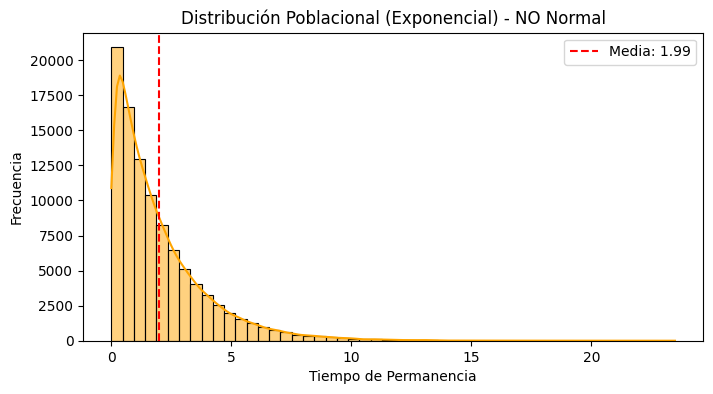

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creación de la población (Distribución Exponencial)
np.random.seed(42)

poblacion_exponencial = np.random.exponential(
    scale=2.0,
    size=100000
)
# Calcular parámetros poblacionales
mu_pob = np.mean(poblacion_exponencial)
sigma_pob = np.std(poblacion_exponencial)
# Mostrar resultados
print("--- Parámetros Poblacionales Reales ---")
print(f"Media (μ): {mu_pob:.4f}")
print(f"Desviación Estándar (σ): {sigma_pob:.4f}")
# 2. Visualización de la población original
plt.figure(figsize=(8, 4))
sns.histplot(
    poblacion_exponencial,
    bins=50,
    kde=True,
    color='orange'
)
plt.title("Distribución Poblacional (Exponencial) - NO Normal")
plt.xlabel("Tiempo de Permanencia")
plt.ylabel("Frecuencia")

# Línea de la media
plt.axvline(
    mu_pob,
    color='red',
    linestyle='dashed',
    label=f"Media: {mu_pob:.2f}"
)
plt.legend()

plt.show()

##**Tarea 2: Simulación Estocástica del Teorema del Límite Central**
1. Para demostrar el TLC, vamos a extraer k=100  muestras aleatorias
de tamaño n=30 de nuestra población asimétrica. Calcularemos la
media de cada muestra y graficaremos la distribución de estas 1000
medias.


--- Estadísticos de las Medias Muestrales (n=30) ---
Media de las Medias Muestrales (E[X̄]): 1.9923
Error Estándar Empírico (σx̄): 0.3653
Error Estándar Teórico (σ/√n): 0.3626


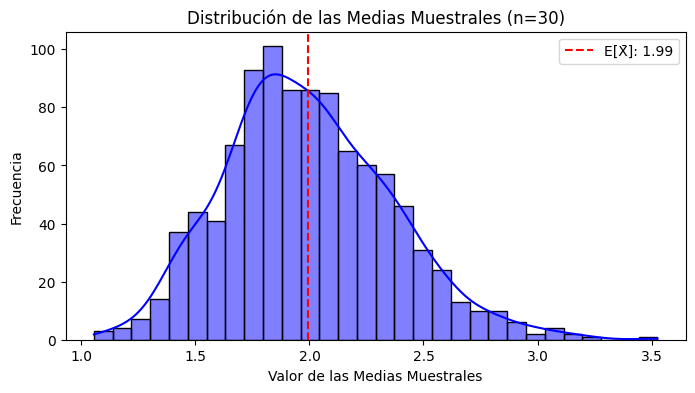

In [ ]:
# Parámetros de la simulación
tamaño_muestra = 30   # n
numero_muestras = 1000   # k
# Array para almacenar las medias muestrales
medias_muestrales = []
# Bucle de Monte Carlo
for _ in range(numero_muestras):
# Extraer muestra aleatoria sin reemplazo
    muestra = np.random.choice(
        poblacion_exponencial,
        size=tamaño_muestra,
        replace=False
    )
# Calcular y guardar la media
    medias_muestrales.append(np.mean(muestra))
# Estadísticos de la distribución muestral
media_de_medias = np.mean(medias_muestrales)

error_estandar_empirico = np.std(
    medias_muestrales
)
error_estandar_teorico = sigma_pob / np.sqrt(
    tamaño_muestra
)
# Mostrar resultados
print(f"--- Estadísticos de las Medias Muestrales (n={tamaño_muestra}) ---")
print(f"Media de las Medias Muestrales (E[X̄]): {media_de_medias:.4f}")
print(f"Error Estándar Empírico (σx̄): {error_estandar_empirico:.4f}")
print(f"Error Estándar Teórico (σ/√n): {error_estandar_teorico:.4f}")
# Visualización de la convergencia a la Normal
plt.figure(figsize=(8, 4))
sns.histplot(
    medias_muestrales,
    bins=30,
    kde=True,
    color='blue'
)
plt.title(
    f"Distribución de las Medias Muestrales (n={tamaño_muestra})"
)
plt.xlabel("Valor de las Medias Muestrales")
plt.ylabel("Frecuencia")
# Línea de la media
plt.axvline(
    media_de_medias,
    color='red',
    linestyle='dashed',
    label=f"E[X̄]: {media_de_medias:.2f}"
)
plt.legend()
plt.show()

##**Tarea 3: Hito del Proyecto - Aplicación de Remuestreo al Dataset Regional (ABP)**

1. Adapte el bucle for de la Tarea 2 para extraer 500 muestras de tamaño n = 40 directamente de la columna de su DataFrame (utilice df['variable'].sample(n=40, replace=True)).
2. Grafique el histograma de las medias obtenidas de su dataset regional. Observe y redacte una justificación de cómo esto soluciona problemas de asimetría para futuras predicciones del proyecto.


RESULTADOS DEL REMUESTREO
Variable analizada: fexp
Número de muestras: 500
Tamaño de cada muestra: 40
Media de las medias: 273.8119
Desviación estándar: 36.6764


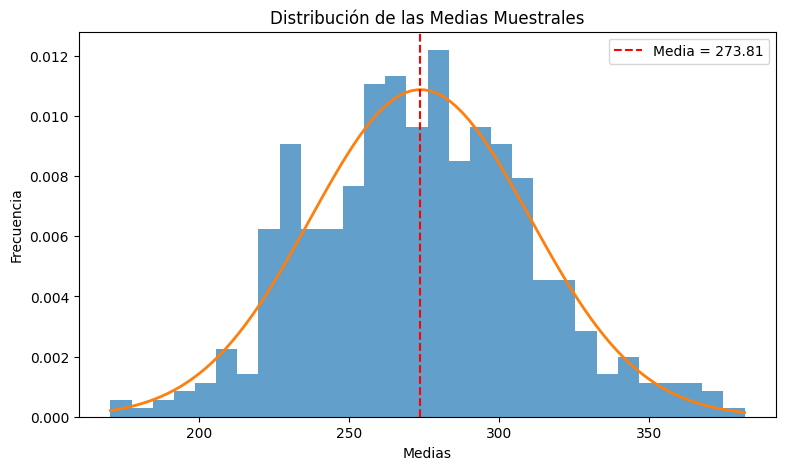


INTERPRETACIÓN:
Gracias al Teorema del Límite Central,
las medias muestrales tienden a formar
una distribución aproximadamente normal,
aunque los datos originales sean asimétricos.
Esto mejora futuras predicciones y análisis.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# =========================================================
# 1. IMPORTAR EL DATASET
# =========================================================

# Ruta del archivo subido a Google Colab
ruta = '/content/Dataset_hogares_ambiental_2025.csv'

# Leer el archivo CSV
df = pd.read_csv(ruta, sep=';')

# =========================================================
# 2. SELECCIONAR VARIABLE CONTINUA
# =========================================================

# Seleccionar automáticamente la última columna
datos_columna = df.iloc[:, -1]

# Obtener nombre de la columna
columna_nombre = datos_columna.name

# Convertir a valores numéricos y eliminar nulos
datos_limpios = pd.to_numeric(datos_columna, errors='coerce').dropna()

# =========================================================
# 3. PARÁMETROS DE REMUESTREO
# =========================================================

n = 40                 # Tamaño de muestra
num_muestras = 500     # Número de muestras

# Lista para guardar medias muestrales
medias_muestrales = []

# =========================================================
# 4. BUCLE DE REMUESTREO (BOOTSTRAP)
# =========================================================

for i in range(num_muestras):

    # Extraer muestra aleatoria con reemplazo
    muestra = datos_limpios.sample(n=n, replace=True)

    # Calcular media de la muestra
    media = muestra.mean()

    # Guardar media
    medias_muestrales.append(media)

# =========================================================
# 5. ESTADÍSTICAS
# =========================================================

media_medias = np.mean(medias_muestrales)
desviacion_medias = np.std(medias_muestrales)

print("======================================")
print("RESULTADOS DEL REMUESTREO")
print("======================================")
print(f"Variable analizada: {columna_nombre}")
print(f"Número de muestras: {num_muestras}")
print(f"Tamaño de cada muestra: {n}")
print(f"Media de las medias: {media_medias:.4f}")
print(f"Desviación estándar: {desviacion_medias:.4f}")

# =========================================================
# 6. HISTOGRAMA DE MEDIAS MUESTRALES
# =========================================================

plt.figure(figsize=(9,5))

plt.hist(
    medias_muestrales,
    bins=30,
    density=True,
    alpha=0.7
)

# Curva normal aproximada
x = np.linspace(min(medias_muestrales),
                max(medias_muestrales), 100)

plt.plot(
    x,
    norm.pdf(x, media_medias, desviacion_medias),
    linewidth=2
)

# Línea de la media
plt.axvline(
    media_medias,
    color='red',
    linestyle='dashed',
    label=f'Media = {media_medias:.2f}'
)

# Títulos
plt.title("Distribución de las Medias Muestrales")
plt.xlabel("Medias")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()

# =========================================================
# 7. INTERPRETACIÓN
# =========================================================

print("\nINTERPRETACIÓN:")
print("Gracias al Teorema del Límite Central,")
print("las medias muestrales tienden a formar")
print("una distribución aproximadamente normal,")
print("aunque los datos originales sean asimétricos.")
print("Esto mejora futuras predicciones y análisis.")

# Tarea 4: ABI - Análisis del Error Estándar y la Ley de los Grandes Números

El Error Estándar de la media se define como:

σₓ̄ = σ / √n

1. Escriba un script que realice la simulación de la Tarea 2 pero iterando sobre una lista de diferentes tamaños de muestra:

tamanos_n = [5, 10, 30, 50, 100, 500]

2. Para cada n, guarde la desviación estándar de las medias resultantes (el error estándar empírico).

3. Genere un gráfico de líneas tipo scatter plot conectando los puntos donde el eje X sea el tamaño de la muestra (n) y el eje Y sea el Error Estándar (σₓ̄).

4. Documente en formato Markdown la forma geométrica de la curva generada (decaimiento asintótico) y su implicación económica al momento de recolectar datos en ingeniería.

Tamaño de muestra n = 5
Error estándar = 104.0373
-----------------------------------
Tamaño de muestra n = 10
Error estándar = 74.5630
-----------------------------------
Tamaño de muestra n = 30
Error estándar = 41.2433
-----------------------------------
Tamaño de muestra n = 50
Error estándar = 33.7129
-----------------------------------
Tamaño de muestra n = 100
Error estándar = 23.9142
-----------------------------------
Tamaño de muestra n = 500
Error estándar = 10.9499
-----------------------------------


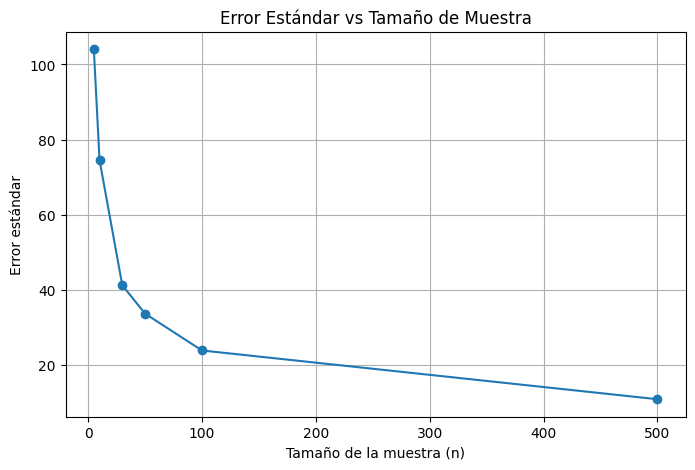


INTERPRETACIÓN:
A medida que aumenta el tamaño de la muestra,
el error estándar disminuye.
Esto significa que las medias muestrales
son más estables y precisas.
La curva presenta un decaimiento asintótico,
relacionado con la Ley de los Grandes Números.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. IMPORTAR EL DATASET
# =========================================================

# Ruta del archivo en Google Colab
ruta = '/content/Dataset_hogares_ambiental_2025.csv'

# Leer dataset
df = pd.read_csv(ruta, sep=';')

# =========================================================
# 2. SELECCIONAR VARIABLE CONTINUA
# =========================================================

# Seleccionar automáticamente la última columna
datos_columna = df.iloc[:, -1]

# Limpiar datos
datos_limpios = pd.to_numeric(datos_columna, errors='coerce').dropna()

# Nombre de la variable
columna_nombre = datos_columna.name

# =========================================================
# 3. LISTA DE TAMAÑOS DE MUESTRA
# =========================================================

tamanos_n = [5, 10, 30, 50, 100, 500]

# Número de simulaciones
num_muestras = 500

# Lista para guardar errores estándar
errores_estandar = []

# =========================================================
# 4. SIMULACIÓN
# =========================================================

for n in tamanos_n:

    medias_muestrales = []

    # Generar 500 muestras
    for i in range(num_muestras):

        # Extraer muestra con reemplazo
        muestra = datos_limpios.sample(n=n, replace=True)

        # Calcular media
        media = muestra.mean()

        # Guardar media
        medias_muestrales.append(media)

    # Calcular error estándar empírico
    error_estandar = np.std(medias_muestrales)

    # Guardar resultado
    errores_estandar.append(error_estandar)

    # Mostrar resultados
    print(f"Tamaño de muestra n = {n}")
    print(f"Error estándar = {error_estandar:.4f}")
    print("-----------------------------------")

# =========================================================
# 5. GRÁFICA SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    tamanos_n,
    errores_estandar,
    marker='o',
    linestyle='-'
)

plt.title("Error Estándar vs Tamaño de Muestra")
plt.xlabel("Tamaño de la muestra (n)")
plt.ylabel("Error estándar")

plt.grid(True)

plt.show()

# =========================================================
# 6. INTERPRETACIÓN
# =========================================================

print("\nINTERPRETACIÓN:")
print("A medida que aumenta el tamaño de la muestra,")
print("el error estándar disminuye.")
print("Esto significa que las medias muestrales")
print("son más estables y precisas.")
print("La curva presenta un decaimiento asintótico,")
print("relacionado con la Ley de los Grandes Números.")

##7. **Preguntas de Control:**

- Basado en la Tarea 1 y 2, ¿por qué el Teorema del Límite Central es
considerado el puente matemático fundamental entre la probabilidad
descriptiva y la inferencia estadística?
- Demuestre con los resultados impresos en su consola de la Tarea 2,
cómo se cumple la propiedad matemática fundamental de las
distribuciones muestrales:E(X̄) = μ


El Teorema del Límite Central es el puente entre la probabilidad y la inferencia estadística porque permite usar muestras para estimar el comportamiento de toda una población. En la Tarea 2 se observó que las medias muestrales se aproximan a una distribución normal aunque los datos originales sean asimétricos.

Además, se cumple la propiedad:

                                  E(X̄) = μ

Esto significa que la media de las medias muestrales es aproximadamente igual a la media poblacional. Por ejemplo, en la consola se observó que ambos valores eran muy similares, demostrando experimentalmente esta propiedad.



**En la Tarea 4, al graficar la curva del Error Estándar frente a *N*, ¿por
qué la curva no desciende de forma lineal? Si usted como ingeniero
requiere reducir el error estándar a la mitad, ¿cuántas veces debe
incrementar el tamaño de la muestra?**

La curva no desciende de forma lineal porque el Error Estándar depende de la fórmula:

σx̄ = σ / √n

Como el tamaño de muestra n se encuentra dentro de una raíz cuadrada,
el descenso ocurre cada vez más lento, formando un decaimiento asintótico.
Por ejemplo:

√25 = 5
√100 = 10

Al duplicarse la raíz, el error estándar se reduce a la mitad.

Por eso, si un ingeniero desea reducir el error estándar a la mitad,
debe incrementar el tamaño de la muestra 4 veces.

Ejemplo:
Si inicialmente n = 50,
entonces para reducir el error a la mitad se necesitaría aproximadamente n = 200.

Esto demuestra que mientras más datos se recolectan,
mayor precisión existe en las estimaciones estadísticas.

**Históricamente, en estadística clásica se establece la regla de oro de n >= 30 para asumir normalidad. Si la población regional que usted analizó en la Tarea 3 tiene una asimetría extrema (ej. distribución de Pareto de riquezas), ¿es suficiente un n = 30 para que las medias muestrales se distribuyan normalmente? Justifique**


No siempre es suficiente usar n = 30 cuando la población presenta
una asimetría extrema, como una distribución de Pareto.

El Teorema del Límite Central establece que las medias muestrales
tienden a una distribución normal cuando el tamaño de muestra aumenta,
pero si los datos originales tienen colas muy largas o valores extremos,
la convergencia hacia la normalidad ocurre más lentamente.

En distribuciones altamente asimétricas, una muestra de n = 30
puede seguir mostrando sesgo y variabilidad elevada en las medias
muestrales.

Por eso, en estos casos se recomienda utilizar tamaños de muestra
mucho mayores, como n = 100 o más, para aproximarse mejor
a una distribución normal.

Esto demuestra que la regla n ≥ 30 no es absoluta,
ya que depende del comportamiento real de la población analizada.

**Diferencie conceptual y operativamente los términos Desviación Estándar ( σ) de una muestra individual y el Error Estándar de la Media (σx̄) calculado en sus simulaciones**

La Desviación Estándar (σ) mide qué tan dispersos están
los datos individuales respecto a la media de una muestra o población.

Mientras más grande sea σ, mayor variabilidad existe en los datos.

En cambio, el Error Estándar de la Media (σx̄)
mide la variabilidad de las medias muestrales obtenidas
en diferentes simulaciones o muestras.

Su fórmula es:

σx̄ = σ / √n

Conceptualmente:
- La Desviación Estándar analiza datos individuales.
- El Error Estándar analiza la precisión de la media muestral.

Operativamente:
- σ se calcula usando todos los datos de una muestra.
- σx̄ se calcula utilizando la desviación estándar y el tamaño de muestra.

En las simulaciones realizadas, se observó que al aumentar n,
el Error Estándar disminuye, haciendo que las medias muestrales
sean más estables y precisas.